### 工作進度  
* 【置頂】**筆記內容架構**與**量化技術分析系統**相關資訊請參閱[260531筆記.ipynb](https://github.com/yilintung/StockInvestmentNotebook/blob/main/260531%E7%AD%86%E8%A8%98.ipynb)之「工作進度」。  

* 引入模組與定義公用函式  

In [ ]:
import numpy as np
import mysys
import markdown
from IPython.core.display import HTML

In [ ]:
def stock_analysis( analysis, stock_id, buttom_pattern = False) :
    results,images = analysis.analysis(stock_id)
    if results is not None :
        if buttom_pattern is True and '底部型態' in images :
            print('底型反轉交易策略：')
            display(images['底部型態'])
        print('解盤內容：')
        if '整體評價' in images and images['整體評價'] is not None  :
            display(images['整體評價'])
        result_md   = results.to_markdown(tablefmt="grid")
        result_html = markdown.markdown(result_md, extensions=['markdown_grid_tables:GridTableExtension'])
        display(HTML(result_html))

* 更新量化技術分析資料庫  

In [ ]:
mysys.UpdateStockDatabase()

* 建立「解盤」物件    

In [ ]:
analysis = mysys.StockAnalysis()

### 大盤解盤  

* 加權指數  

> **開盤**：加權指數平盤小低，不過支撐都有守住。  
> 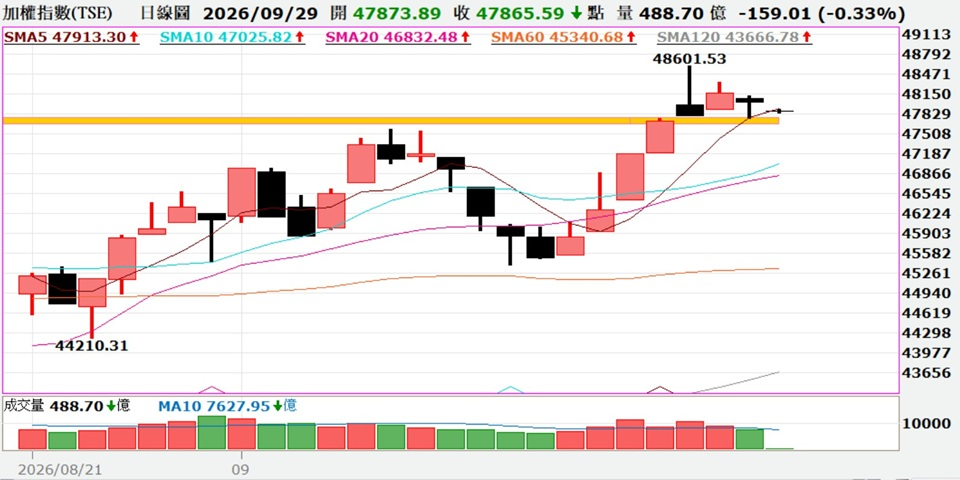  

> **盤後**：量化技術分析  

In [ ]:
# 盤後：加權指數解盤
stock_analysis(analysis,'TAIEX')

* 櫃買指數  

> **開盤**：櫃買指數也還穩定。  
> 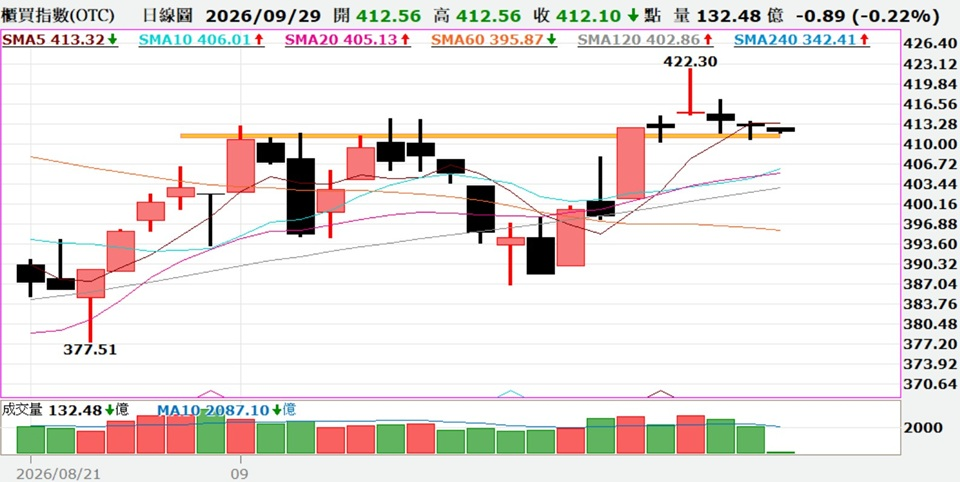  

> **盤後**：量化技術分析  

In [ ]:
# 盤後：櫃買指數解盤
stock_analysis(analysis,'TPEx')

### 個股篩選  

* 選股程序    

In [ ]:
results = analysis.screener()

In [ ]:
for stock_info in results :
    print('股票代碼 ＝ {} ， 股票名稱 ＝ {} '.format(stock_info[0],stock_info[1]))

* 篩選結果  
  - 聯傑(3094)：強勢多頭  
    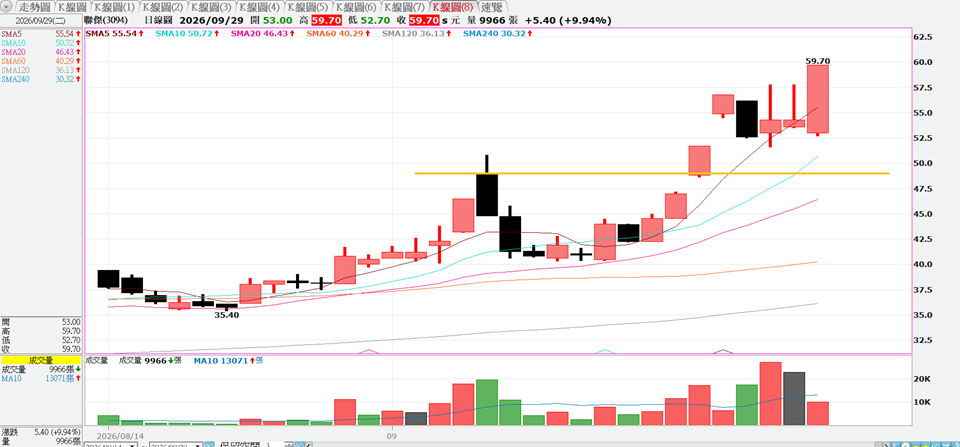  
  - 彰源(2030)：強勢多頭  
    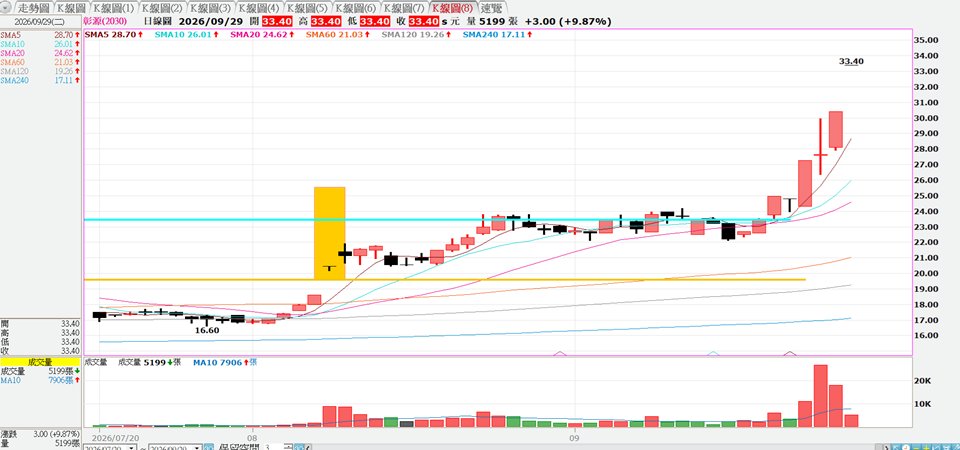  
  - 浩鼎(4174)：穩健續漲  
    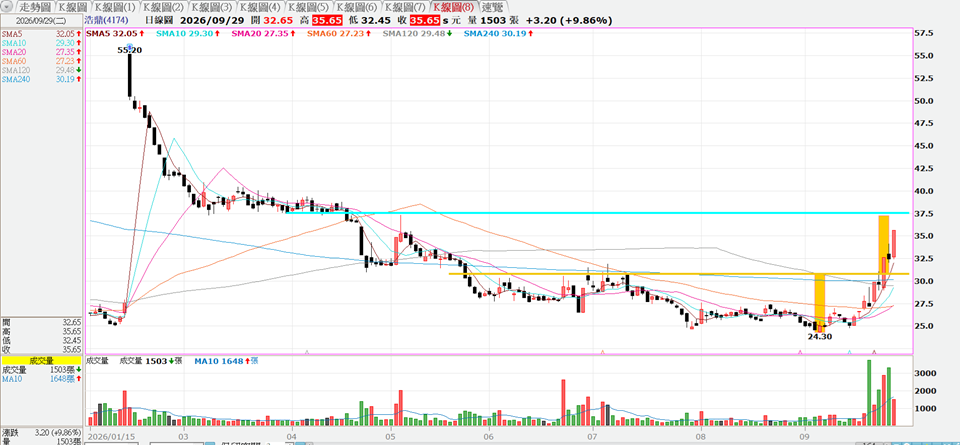   
  - 茂矽(2342)：穩健續漲  
    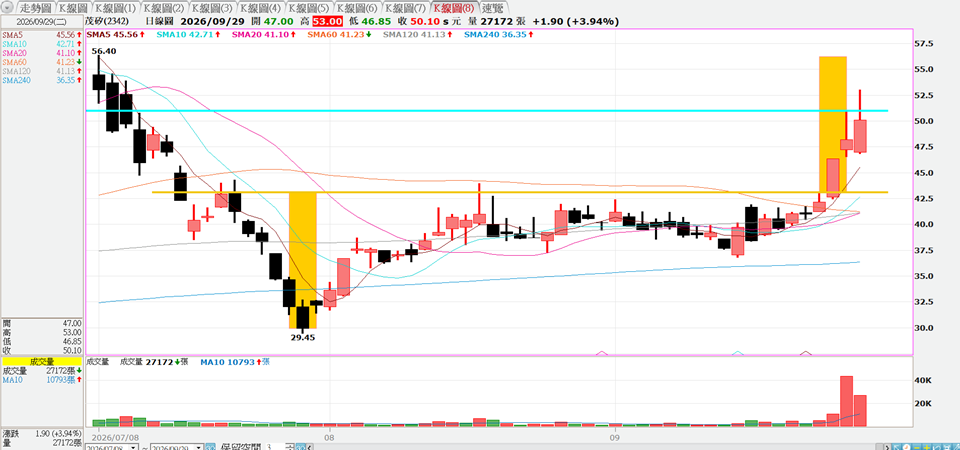  
  - 擎邦(6122)：已到目標價  
    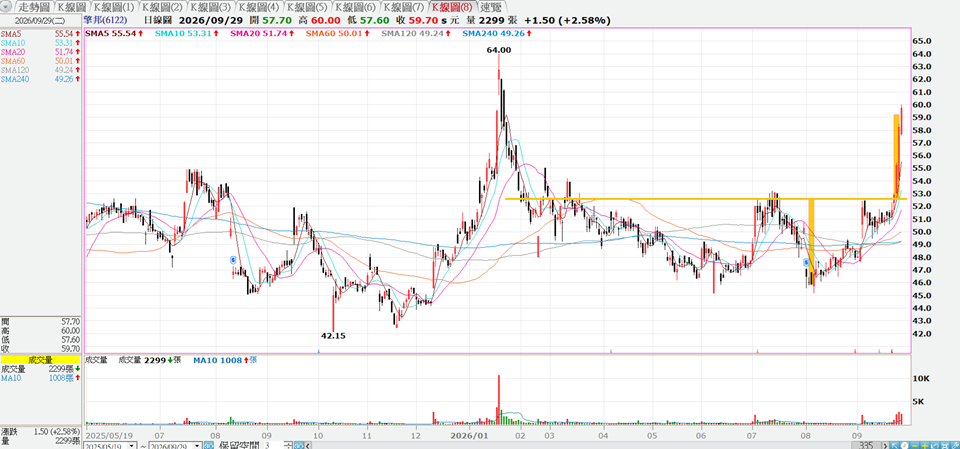  
  - 中釉(1809)：多頭回檔  
    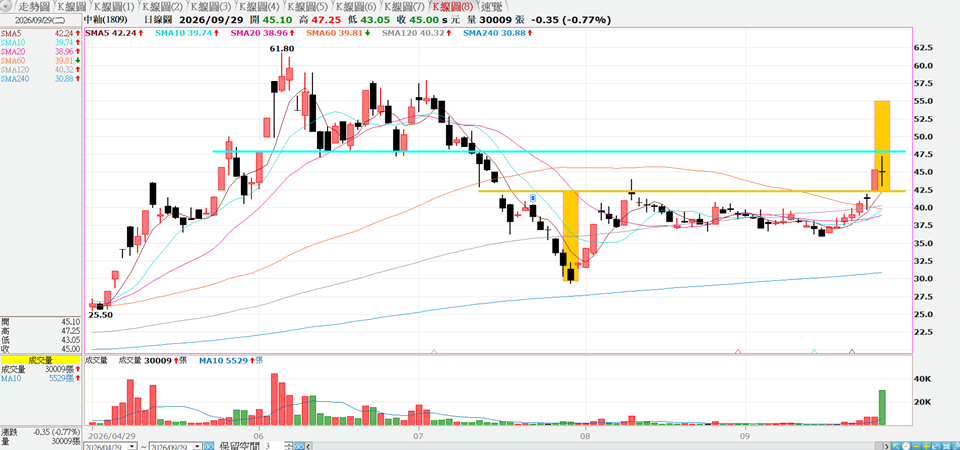  

* 觀察股列表  
  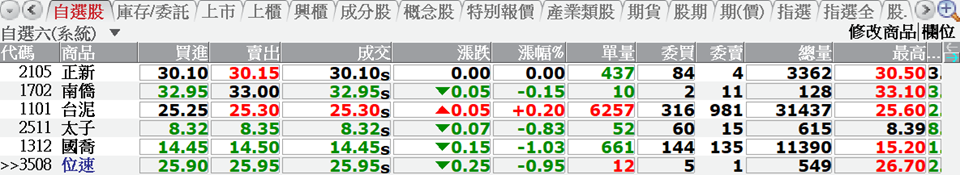  

* 技術面+籌碼面分類整理表  
  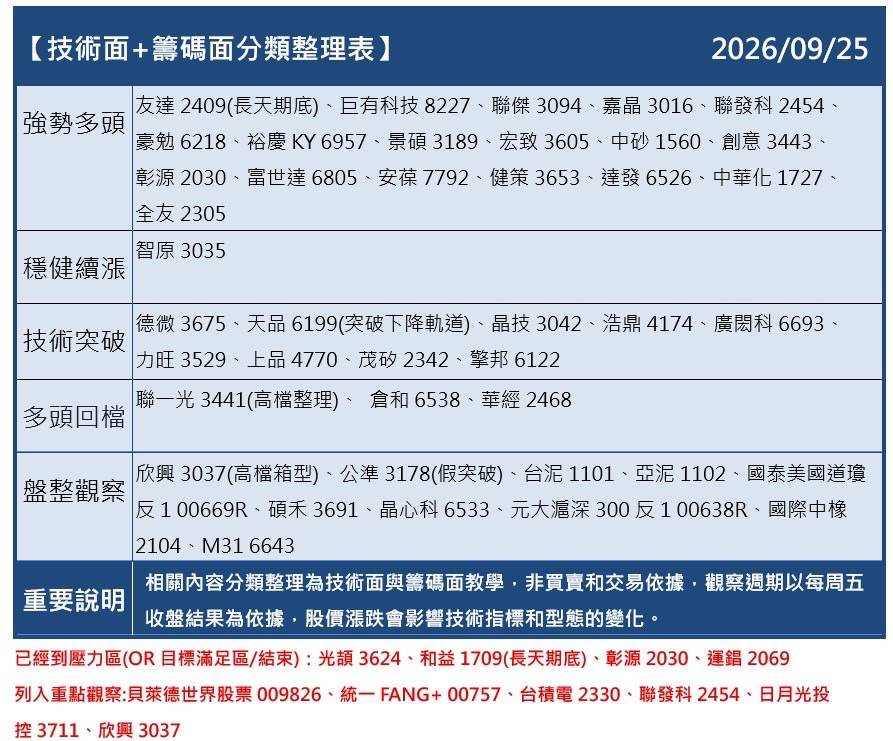  

### 個股解盤  

* 位速(3508)  
  看法：頸線之上狹幅整理。  

> **盤後**：量化技術分析  

In [ ]:
stock_analysis(analysis,'3508')

> **盤後**：底部反轉交易策略分析  

In [ ]:
def line_drawing_callback( range_prices) :
    # 設定頸線
    neckline_start_date  = '2026-03-31'
    neckline_end_date    = range_prices.iloc[-1].name.strftime("%Y-%m-%d")
    neckline_x           = [mysys.DateToIndex(range_prices,'2026-04-23'),mysys.DateToIndex(range_prices,'2026-08-24')]
    neckline_y           = [range_prices.loc['2026-04-23']['Open'],range_prices.loc['2026-08-24']['Open']]
    slope,intercept      = np.polyfit(neckline_x,neckline_y,1)
    neckline_start_price = slope * mysys.DateToIndex(range_prices,neckline_start_date) + intercept
    neckline_end_price   = slope * mysys.DateToIndex(range_prices,neckline_end_date) + intercept

    # 設定底部日期與價格
    bottom_date           = '2026-07-29'
    bottom_price          = range_prices.loc['2026-07-29']['Open']
    neckline_bottom_price = slope * mysys.DateToIndex(range_prices,bottom_date) + intercept

    # 設定突破日期
    breakout_date           = '2026-09-21'
    neckline_breakout_price = slope * mysys.DateToIndex(range_prices,breakout_date) + intercept

     # 估算目標價
    target_price = (neckline_breakout_price - bottom_price) + neckline_breakout_price
    print('估算目標價為{:.2f}元'.format(target_price))
    
    seq_of_seq_of_points=[
        [(neckline_start_date,neckline_start_price),(neckline_end_date,neckline_end_price)],
        [(bottom_date,bottom_price),(bottom_date,neckline_bottom_price)],
        [(breakout_date,neckline_breakout_price),(breakout_date,target_price)]
    ]

    linewidths=[2.0,15.0,15.0]
    
    colors=['xkcd:orange yellow','xkcd:orange yellow','xkcd:orange yellow']
    
    return seq_of_seq_of_points,linewidths,colors

In [ ]:
image = mysys.DrawOnKlineChart('3508','2026-01-19','2026-09-29',line_drawing_callback)
display(image)

籌碼面：  
法人○○( )：外資○○( )、投信○○( )、自營○○( )。  
主力○○( )。  
分公司買賣家數差○○( )。  
融資○○( )、融券○○( )。  